#### Not

##### Verileri temizlemeden önceki kullandığımız grafiklerin aynısını temizlikten sonraki veriler içinden uygulancak


In [1]:
%run model.ipynb

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17201 entries, 0 to 17200
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Net_Metrekare                    17201 non-null  float64
 1   Brüt_Metrekare                   17201 non-null  float64
 2   Oda_Sayısı                       17201 non-null  float64
 3   Binanın_Yaşı                     17201 non-null  float64
 4   Fiyat                            17201 non-null  float64
 5   Şehir                            17201 non-null  float64
 6   Binanın_Kat_Sayısı               17201 non-null  float64
 7   Kullanım_Durumu                  17201 non-null  float64
 8   Banyo_Sayısı                     17201 non-null  float64
 9   Apartman_Mi                      17201 non-null  float64
 10  Zemin_Mi                         17201 non-null  float64
 11  Cati_Mi                          17201 non-null  float64
 12  Isıtma_Tipi_Doğalg

In [2]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

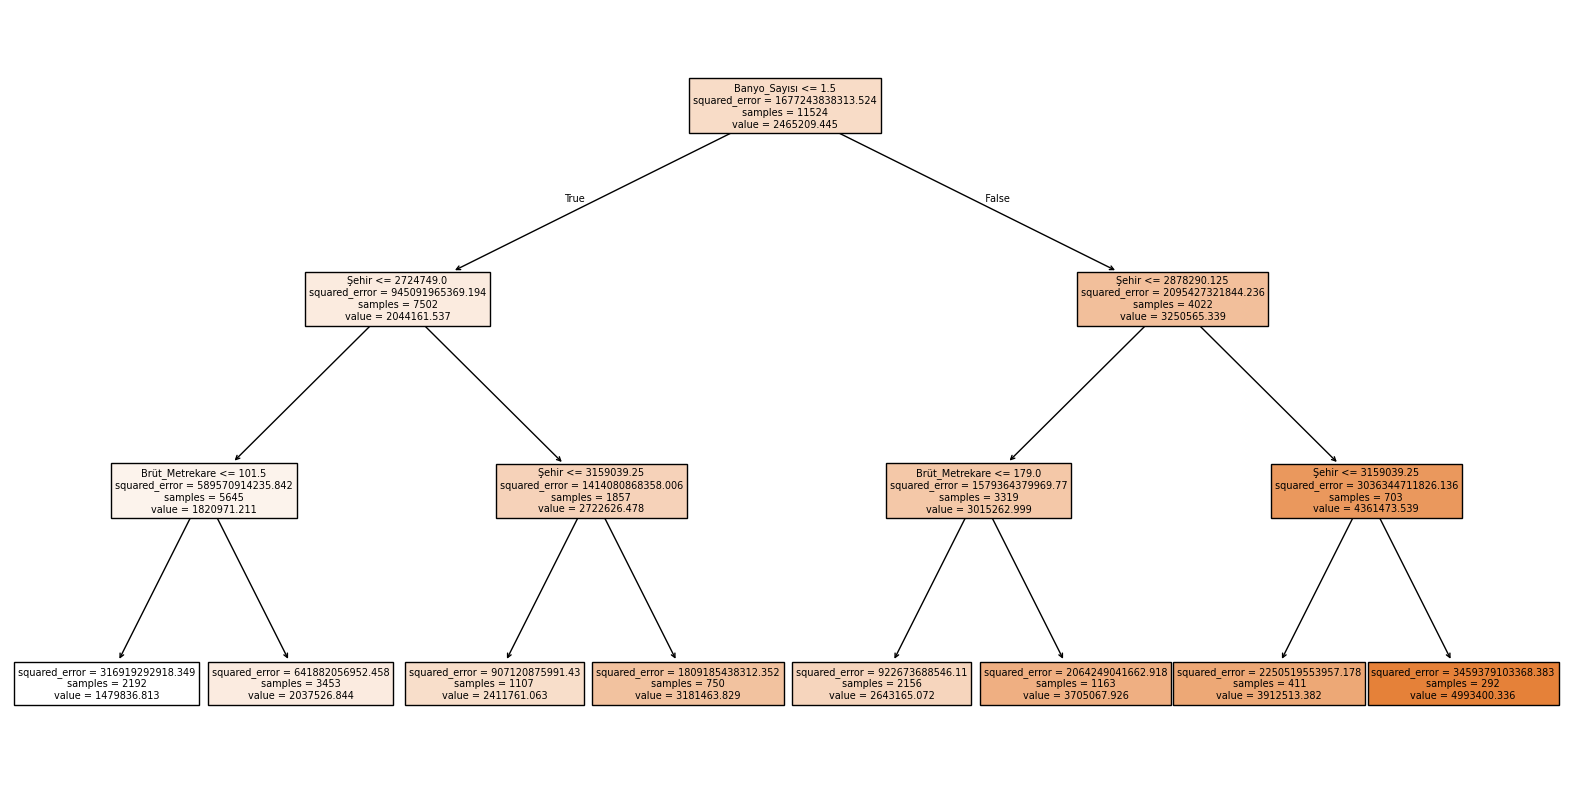

In [3]:

plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=x.columns,
    filled=True
)

plt.show()

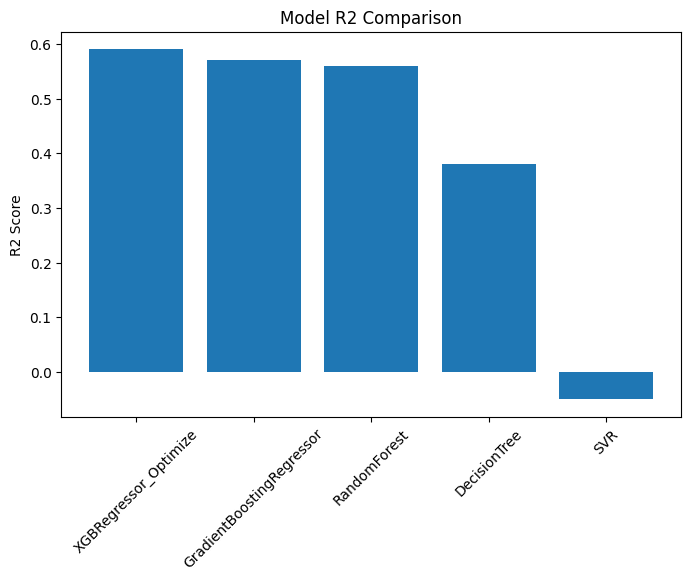

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2"])

plt.title("Model R2 Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)

plt.show()

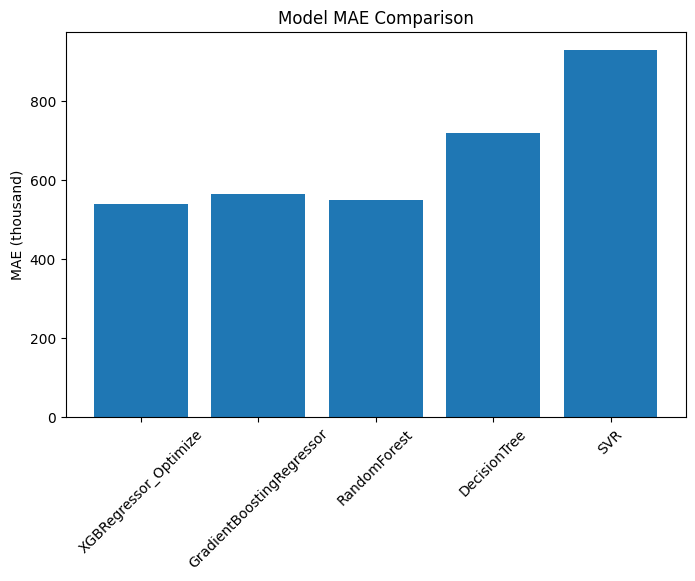

In [5]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["MAE"])

plt.title("Model MAE Comparison")
plt.ylabel("MAE (thousand)")
plt.xticks(rotation=45)

plt.show()

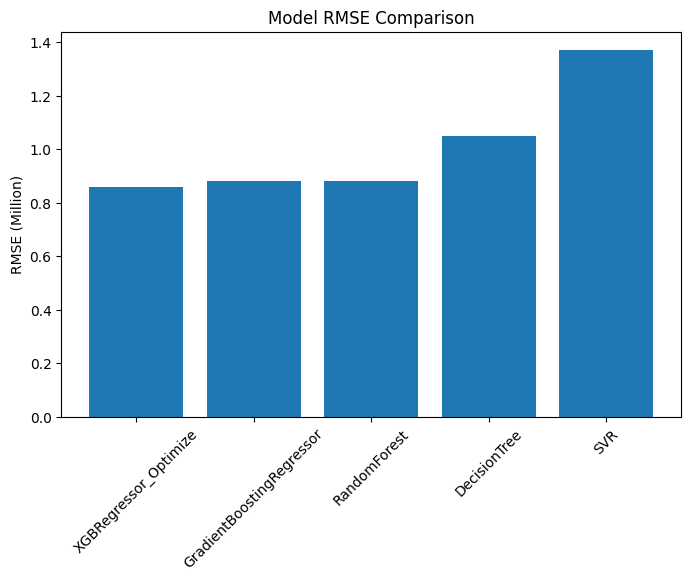

In [6]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model RMSE Comparison")
plt.ylabel("RMSE (Million)")
plt.xticks(rotation=45)

plt.show()

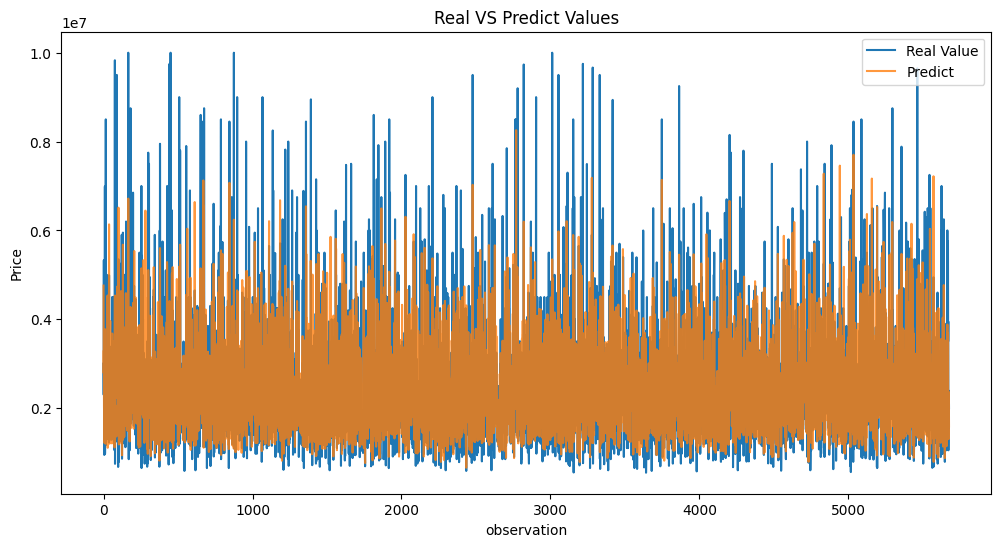

In [7]:
plt.figure(figsize=(12,6))


plt.plot(y_test.values, label="Real Value")
plt.plot(y_pred_best, label="Predict", alpha=0.8)

plt.title("Real VS Predict Values")
plt.xlabel("observation")
plt.ylabel("Price")

plt.legend()
plt.show()

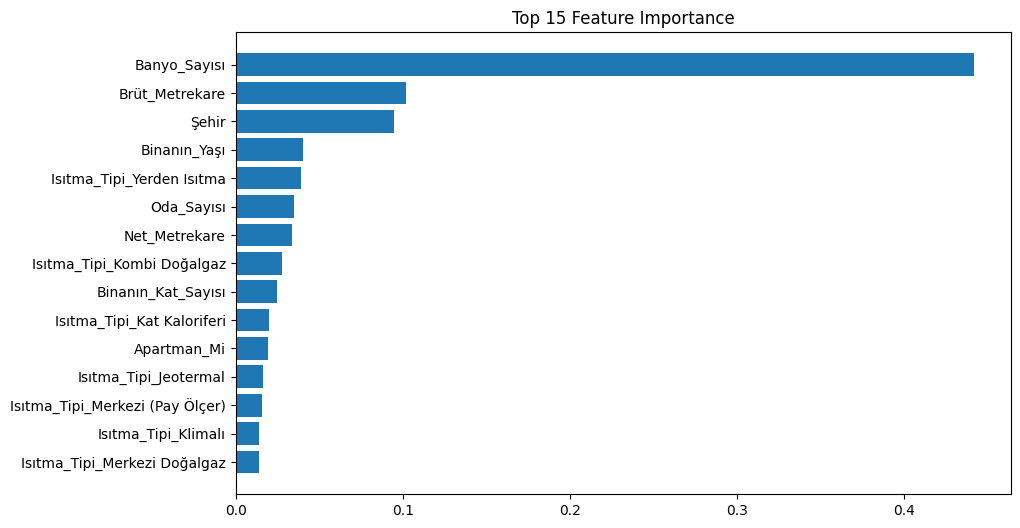

In [8]:
import pandas as pd

importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 15 Feature Importance")
plt.gca().invert_yaxis()

plt.show()

Text(0.5, 1.0, 'Real vs Predict')

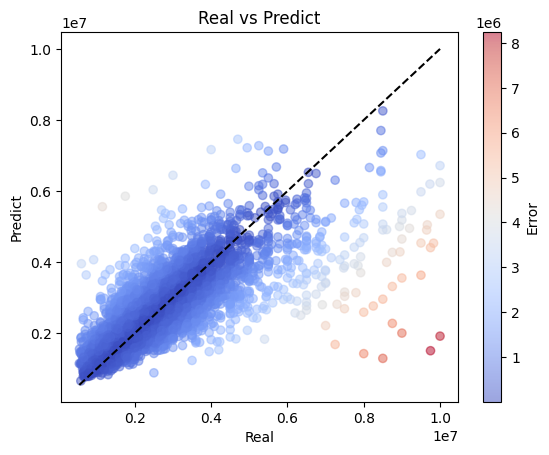

In [9]:
plt.scatter(y_test, y_pred_best, alpha=0.5, c=np.abs(y_test - y_pred_best), cmap='coolwarm')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--')

plt.colorbar(label="Error")
plt.xlabel("Real")
plt.ylabel("Predict")
plt.title("Real vs Predict")